In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Zadanie 1**

napisz funkcję, która będzie w stanie wyświetlić podobny wykres dla danych ze zbioru FIFA22_official_data.csv (podfolder **data**). Założenia:

* funkcja przyjmuje jako wektor pandas DataFrame, w którym pierwsza kolumna to nazwa piłkarza a kolejne kolumny to dowolny podzbiór cech piłkarskich tego zawodnika (od Crossing do GKReflexes),
* funkcja i wykres powinny działać dla zmiennej liczby cech oraz dla zmiennej liczby piłkarzy,
* ustaw stały zakres wartości cech w przedziale [0, 100],
* etykiety osi na wykresie to etykiety kolumn poza nazwą piłkarza,
* każdy piłkarz reprezentowany jest przez inny kolor,
* legenda zawiera również nazwisko piłkarza.


In [95]:
# 0 = brak umiejętności
# 100 = maksymalny poziom

data = pd.read_csv(r"C:\anal_danych\Labs\data\FIFA22_official_data.csv")
ff_features = data.loc[:, 'Crossing':'GKReflexes'] #wybieramy tylko kolumny z umiejętnościami piłkarskimi
players = data.loc[:,['Name']] 



new_data = pd.concat([players, ff_features], axis=1)
print("Marking table has", data['Marking'].isna().sum(), "missing values") #sprawdzenie, ile jest brakujących wartości w kolumnie Marking
new_data = new_data.drop('Marking', axis=1) #nie wliczam kolumne Marking bo nie jest ona wypełniona dla wszystkich zawodników
ff_features = new_data.loc[:, 'Crossing':'GKReflexes']
players = new_data.loc[:,['Name']] 
new_data.head()


Marking table has 15818 missing values


,Name,Crossing,Finishing,HeadingAccuracy,ShortPassing,Volleys,Dribbling,Curve,FKAccuracy,LongPassing,...,Vision,Penalties,Composure,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes
0,Bruno Fernandes,87.0,83.0,64.0,91.0,87.0,83.0,87.0,87.0,88.0,...,90.0,91.0,87.0,73.0,65.0,12.0,14.0,15.0,8.0,14.0
1,L. Goretzka,75.0,82.0,86.0,86.0,69.0,84.0,76.0,75.0,84.0,...,84.0,60.0,82.0,85.0,77.0,13.0,8.0,15.0,11.0,9.0
2,L. Suárez,80.0,93.0,84.0,83.0,90.0,83.0,86.0,82.0,77.0,...,84.0,83.0,87.0,45.0,38.0,27.0,25.0,31.0,33.0,37.0
3,K. De Bruyne,94.0,82.0,55.0,94.0,82.0,88.0,85.0,83.0,93.0,...,94.0,83.0,89.0,65.0,53.0,15.0,13.0,5.0,10.0,13.0
4,M. Acuña,87.0,66.0,58.0,82.0,68.0,87.0,88.0,75.0,78.0,...,82.0,76.0,87.0,84.0,82.0,8.0,14.0,13.0,13.0,14.0


In [102]:
etykiety = ff_features.columns.tolist()
print("Liczba umiejętności:", len(etykiety))
print("Umiejętności:", etykiety)
players_list = players['Name'].tolist()
print("Liczba zawodników:", len(players_list))
print("Players:", players_list)

Liczba umiejętności: 33
Umiejętności: ['Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes']
Liczba zawodników: 16710
Players: ['Bruno Fernandes', 'L. Goretzka', 'L. Suárez', 'K. De Bruyne', 'M. Acuña', 'J. Kimmich', 'Paulinho', 'G. Wijnaldum', 'E. Can', 'A. Griezmann', 'L. Modrić', 'Marcos Llorente', 'Sergio Ramos', 'D. Alaba', 'Merino', 'N. Barella', 'Alex Telles', 'F. de Jong', 'M. Sabitzer', 'J. Cuadrado', 'Koke', 'João Cancelo', 'L. Digne', 'F. Kostić', 'T. Alexander-Arnold', 'S. Milinković-Savić', 'A. Vidal', 'P. Pogba', 'Casemiro', 'L. Messi', 'Renato Sanches', 'L. Ocampos', 'Jordi Alba', '

[91.0, 87.0, 83.0, 64.0]
[86.0, 75.0, 82.0, 86.0]
[83.0, 80.0, 93.0, 84.0]
[94.0, 94.0, 82.0, 55.0]


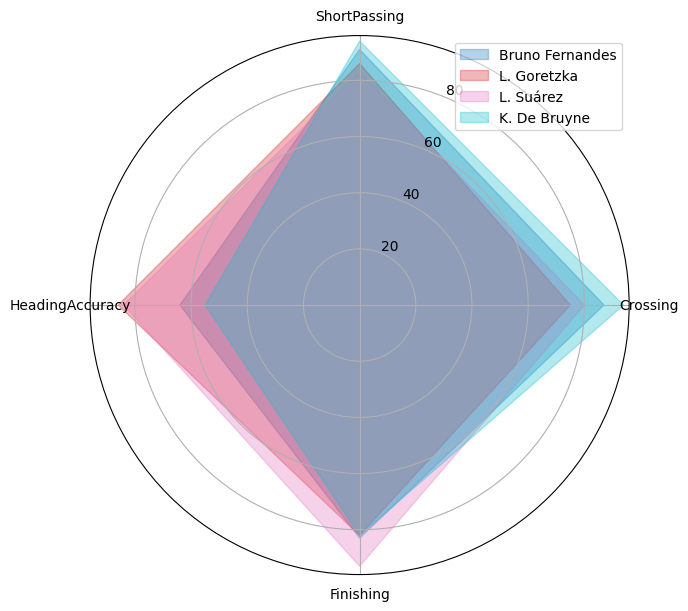

In [133]:
def radar_players(players_ind, features):
    angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
    
    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
    
    #generowanie kolorów dla każdego zawodnika z palety tab10
    colors = plt.cm.tab10(np.linspace(0, 1, len(players_ind)))
    
    ax.set_theta_offset(np.pi / 2)
    
    ax.set_theta_direction(-1)
    
    ax.set_thetagrids(np.degrees(angles), labels=features)
    
    for i in range(len(players_ind)):
        #dane  zawodnika, tylko pierwszy znaleziony rekord
        dane = new_data.loc[new_data['Name'] == players_ind[i], features].iloc[0].values.flatten().tolist()
        print(dane)

        ax.fill(angles, dane, color=colors[i] , alpha=0.33, label = players_ind[i])

    plt.legend();

radar_players(players_ind = ['Bruno Fernandes', 'L. Goretzka', 'L. Suárez','K. De Bruyne'], features = ['ShortPassing','Crossing', 'Finishing', 'HeadingAccuracy'])

In [126]:
players_ind = ['Bruno Fernandes', 'L. Goretzka', 'L. Suárez']
features = ['Crossing', 'Finishing', 'HeadingAccuracy']
dane = new_data.loc[new_data['Name'] == players_ind[0], features].values.tolist()
dane

[[87.0, 83.0, 64.0]]

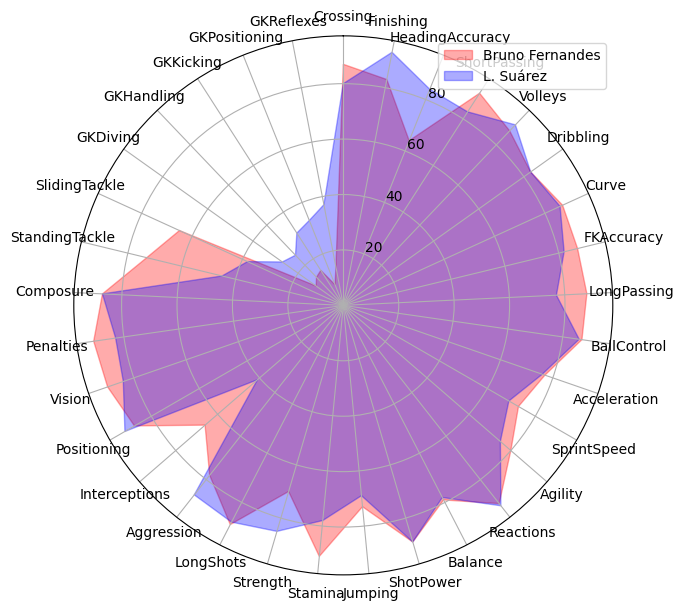

In [97]:

def radar_compare_players(player_1, player_2):
    #dane pierwszego zawodnika
    dane_1 = ff_features.loc[player_1].values.tolist()
    #dane drugiego zawodnika
    dane_2 = ff_features.loc[player_2].values.tolist()

    angles = np.linspace(0, 2*np.pi, len(etykiety), endpoint=False).tolist()
    
    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

    ax.fill(angles, dane_1, color='red', alpha=0.33, label = data['Name'][player_1])
    ax.fill(angles, dane_2, color='blue', alpha=0.33, label = data['Name'][player_2])

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles), labels=etykiety)
    plt.legend()

radar_compare_players(player_1 = 0, player_2 = 2)

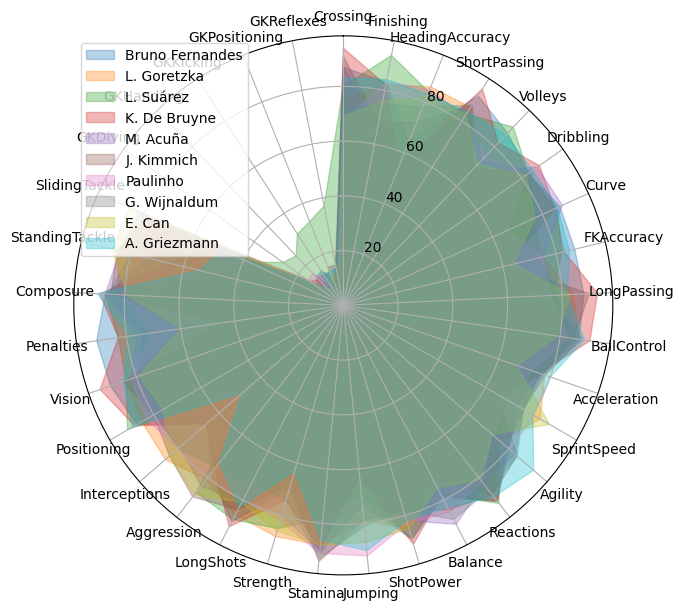

In [99]:
#all players on 1 radar plot

def radar_players(nb_players):
    angles = np.linspace(0, 2*np.pi, len(etykiety), endpoint=False).tolist()
    
    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
    
    #generowanie kolorów dla każdego zawodnika z palety tab10
    colors = plt.cm.tab10(np.linspace(0, 1, nb_players))
    
    ax.set_theta_offset(np.pi / 2)
    
    ax.set_theta_direction(-1)
    
    ax.set_thetagrids(np.degrees(angles), labels=etykiety)
    
    for player_index in range(nb_players):
        #dane  zawodnika
        dane = ff_features.loc[player_index].values.tolist()

        ax.fill(angles, dane, color=colors[player_index] , alpha=0.33, label = data['Name'][player_index])

    plt.legend()

radar_players(nb_players = 10)

In [30]:
np.degrees(0.5*np.pi) #360 stopni

np.float64(90.0)

**Zadanie 2**

- Korzystając ze zbioru danych [pkn.txt](./data/pkn.txt), przygotuj skrypt
- będzie wyświetlał animację wykresu odzwierciedlającą cenę zamknięcia (kolumna `CLOSE`) tego waloru. 
- Na osi y powinna znajdować się cena a na osi x kolejny odczyt tej ceny. 
- Przy pierwszym wyświetleniu wykresu pobierz pierwsze 20 wartości, a następnie przy każdej animacji agreguj kolejny odczyt. 
- W miarę możliwości ustaw takie parametry wykresu, aby linia wykresu nie znajdowała się bezpośrednio przy górnej lub prawej krawędzi płótna.
- Aktualizuj również na osi x daty odczytu wartości waloru w trakcie postępu animacji.

In [ ]:
import matplotlib.animation as FuncAnimation


In [144]:
pkn = pd.read_csv(r"C:\anal_danych\Labs\data\pkn.txt", sep=",")
pkn.columns = [column.replace("<","").replace(">","") for column in pkn.columns] 
pkn.head()

#X → daty kolejnych notowań
#Y -> Y → cena close


,TICKER,PER,DATE,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT
0,PKN,D,19991126,0,15.268,15.403,14.715,15.194,15857000,0
1,PKN,D,19991129,0,15.124,15.194,14.852,14.923,5499196,0
2,PKN,D,19991130,0,15.060,15.330,15.060,15.194,3287087,0
3,PKN,D,19991201,0,15.330,15.674,15.194,15.674,3077747,0
4,PKN,D,19991202,0,15.818,16.297,15.745,15.954,3304014,0


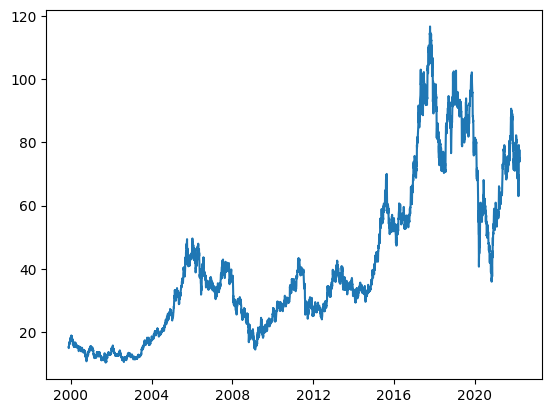

In [ ]:
pkn['DATE'] =pd.to_datetime(pkn['DATE'], format='%Y%m%d')
y_close = pkn['CLOSE']
x_date = pkn['DATE']

fig , ax = plt.subplots()

ax.plot(x_date,y_close)
plt.show()


**Zadanie 3**

Wykorzystując dane [pkn.txt](./data/pkn.txt) wyrysuj wykres liniowy dla ceny zamknięcia i dodaj do wykresu wskaźniki jak w przykładzie z adnotacjami (przykład 2), które wskażą wartość najmniejszą oraz największą.

In [172]:
pkn = pd.read_csv(r"C:\anal_danych\Labs\data\pkn.txt", sep=",")
pkn.columns = [column.replace("<","").replace(">","") for column in pkn.columns] 
pkn.head()
pkn['CLOSE'].idxmax()

4478

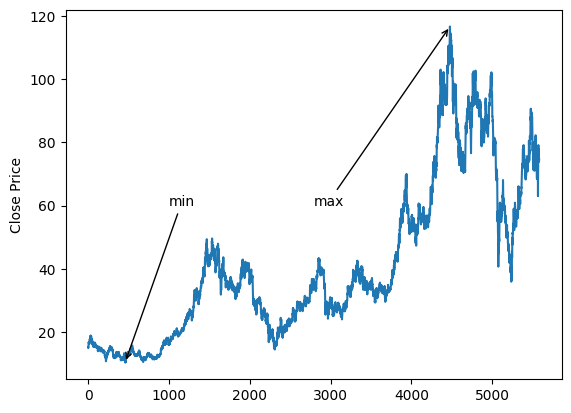

In [183]:
fig,ax = plt.subplots()
ax.set_ylabel('Close Price')

ax.annotate("max",
            xy=(pkn['CLOSE'].idxmax(), pkn['CLOSE'].max()) , xycoords = 'data',
            xytext=(len(pkn['CLOSE'])/2, 60), textcoords='data',
            arrowprops = dict(arrowstyle = "->",
                            connectionstyle = "arc3"))

ax.annotate("min",
            xy = (pkn['CLOSE'].idxmin(), pkn['CLOSE'].min()), xycoords = 'data',
            xytext=(1000,60), textcoords = 'data',
            arrowprops = dict(arrowstyle = "->",
                            connectionstyle = "arc3"))
                            
ax.plot(pkn['CLOSE'])

**Zadanie 4**

Korzystając z danych [pkn.txt](./data/pkn.txt) pogrupuj dane po roku i miesiącu, znajdź wartość minimalną oraz maksymalną dla kolumny `CLOSE`, a następnie za pomocą przykładu formatowania danych z punktu 4 zaznacz wartość minimalną i maksymalną w tej kolumnie różnymi stylami (odpowiednio funkcje highlight_min oraz highlight_max).

In [189]:
pkn = pd.read_csv(r"C:\anal_danych\Labs\data\pkn.txt", sep=",")
pkn.columns = [column.replace("<","").replace(">","") for column in pkn.columns] 
pkn['DATE'] = pd.to_datetime(pkn['DATE'], format='%Y%m%d')
pkn.head()


,TICKER,PER,DATE,TIME,OPEN,HIGH,LOW,CLOSE,VOL,OPENINT
0,PKN,D,1999-11-26,0,15.268,15.403,14.715,15.194,15857000,0
1,PKN,D,1999-11-29,0,15.124,15.194,14.852,14.923,5499196,0
2,PKN,D,1999-11-30,0,15.060,15.330,15.060,15.194,3287087,0
3,PKN,D,1999-12-01,0,15.330,15.674,15.194,15.674,3077747,0
4,PKN,D,1999-12-02,0,15.818,16.297,15.745,15.954,3304014,0


In [ ]:

year = pkn['DATE'].dt.year
month = pkn['DATE'].dt.month
close_minimax = pkn.groupby([year, month]).agg({'CLOSE': ['max', 'min']})


CLOSE        
              max     min
DATE DATE                
1999 11    15.194  14.923
     12    17.950  15.674
2000 1     18.908  17.256
     2     17.806  15.330
     3     16.711  15.268
...           ...     ...
2021 11    89.000  71.300
     12    76.380  70.980
2022 1     82.200  71.000
     2     73.720  62.960
     3     79.100  73.020

[269 rows x 2 columns]

In [ ]:
close_minimax.style.highlight_max(subset=[('CLOSE', 'max')], color='green').highlight_min(subset=[('CLOSE', 'min')], color='red')